In [1]:

%pip install -q pandas scikit-learn scipy matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scipy helps us with the math for hierarchical trees (dendrograms)
from scipy.cluster.hierarchy import dendrogram, linkage
# Scikit-learn is our workhorse for the actual clustering and evaluation
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Making the pandas output a bit more readable
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
# Setting a clean visual style for our plots
plt.style.use("seaborn-v0_8-whitegrid")

# Helper function to plot our clusters in 2D space
def plot_cluster_map(points_2d, labels, title, axis=None, x_label="Component 1", y_label="Component 2"):
    if axis is None:
        axis = plt.gca()

    unique_labels = sorted(np.unique(labels))
    palette = plt.get_cmap("tab10")
    color_index = 0

    for label in unique_labels:
        mask = labels == label
        # Standard convention: DBSCAN labels noise as -1, let's make it black
        if label == -1:
            axis.scatter(
                points_2d[mask, 0],
                points_2d[mask, 1],
                color="black",
                s=45,
                alpha=0.85,
                label="noise",
            )
        else:
            axis.scatter(
                points_2d[mask, 0],
                points_2d[mask, 1],
                color=palette(color_index % 10),
                s=45,
                alpha=0.85,
                label=f"cluster {label}",
            )
            color_index += 1

    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.legend()
    axis.grid(alpha=0.25)

# Calculates how well each point fits in its assigned cluster
def silhouette_details(features, labels):
    unique_labels = np.unique(labels)
    # Silhouette score isn't defined for a single cluster or total noise
    if len(unique_labels) < 2 or len(unique_labels) >= len(labels):
        return np.full(len(labels), np.nan), np.nan

    sample_scores = silhouette_samples(features, labels)
    average_score = silhouette_score(features, labels)
    return sample_scores, float(average_score)

# A quick way to summarize how our model performed
def describe_clustering(features, labels, model_name):
    sample_scores, average_score = silhouette_details(features, labels)
    row = {
        "model": model_name,
        "cluster_count": int(len(set(labels)) - (1 if -1 in labels else 0)),
        "noise_points": int(np.sum(labels == -1)),
        "silhouette_score": average_score,
    }
    return row, sample_scores

# Mathematical trick to find the 'elbow' in the K-distance graph to pick epsilon automatically
def estimate_eps_from_k_distance(sorted_distances):
    x_values = np.arange(len(sorted_distances), dtype=float)
    points = np.column_stack((x_values, sorted_distances))
    start = points[0]
    end = points[-1]
    line_vector = end - start
    line_vector = line_vector / np.linalg.norm(line_vector)

    projected_points = start + np.outer((points - start) @ line_vector, line_vector)
    distances_to_line = np.linalg.norm(points - projected_points, axis=1)
    elbow_index = int(np.argmax(distances_to_line))
    return float(sorted_distances[elbow_index]), elbow_index

In [3]:
from sklearn.datasets import make_blobs

# Let's create some fake data where we know exactly where the clusters are
# This helps us test if our algorithms are behaving as expected
X_syn, y_syn = make_blobs(
    n_samples=[120, 110, 130, 90],
    centers=[(-7, -2), (-1, 4.5), (4.5, -4), (7, 4)],
    cluster_std=[1.0, 0.8, 1.1, 0.7],
    random_state=42,
)

syn_df = pd.DataFrame(X_syn, columns=["feature_1", "feature_2"])
print("Synthetic dataset shape:", X_syn.shape)
display(syn_df.head())

Synthetic dataset shape: (450, 2)


,feature_1,feature_2
0,6.5626,4.0183
1,-6.4850,-1.4862
2,4.6093,-3.1735
3,6.5710,3.7286
4,7.4954,3.6063


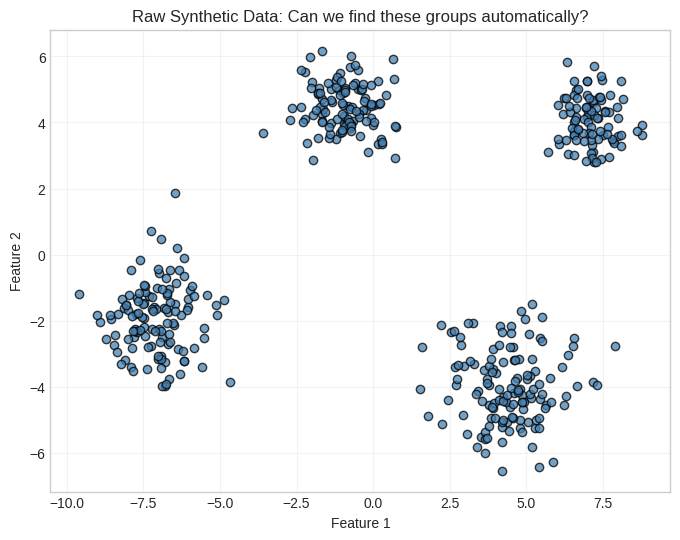

In [4]:
# Visualizing the raw data. It looks like 4 distinct groups,
# which matches how we generated it.
plt.figure(figsize=(8, 6))
plt.scatter(X_syn[:, 0], X_syn[:, 1], color="steelblue", edgecolor="black", alpha=0.75)
plt.title("Raw Synthetic Data: Can we find these groups automatically?")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.25)
plt.show()

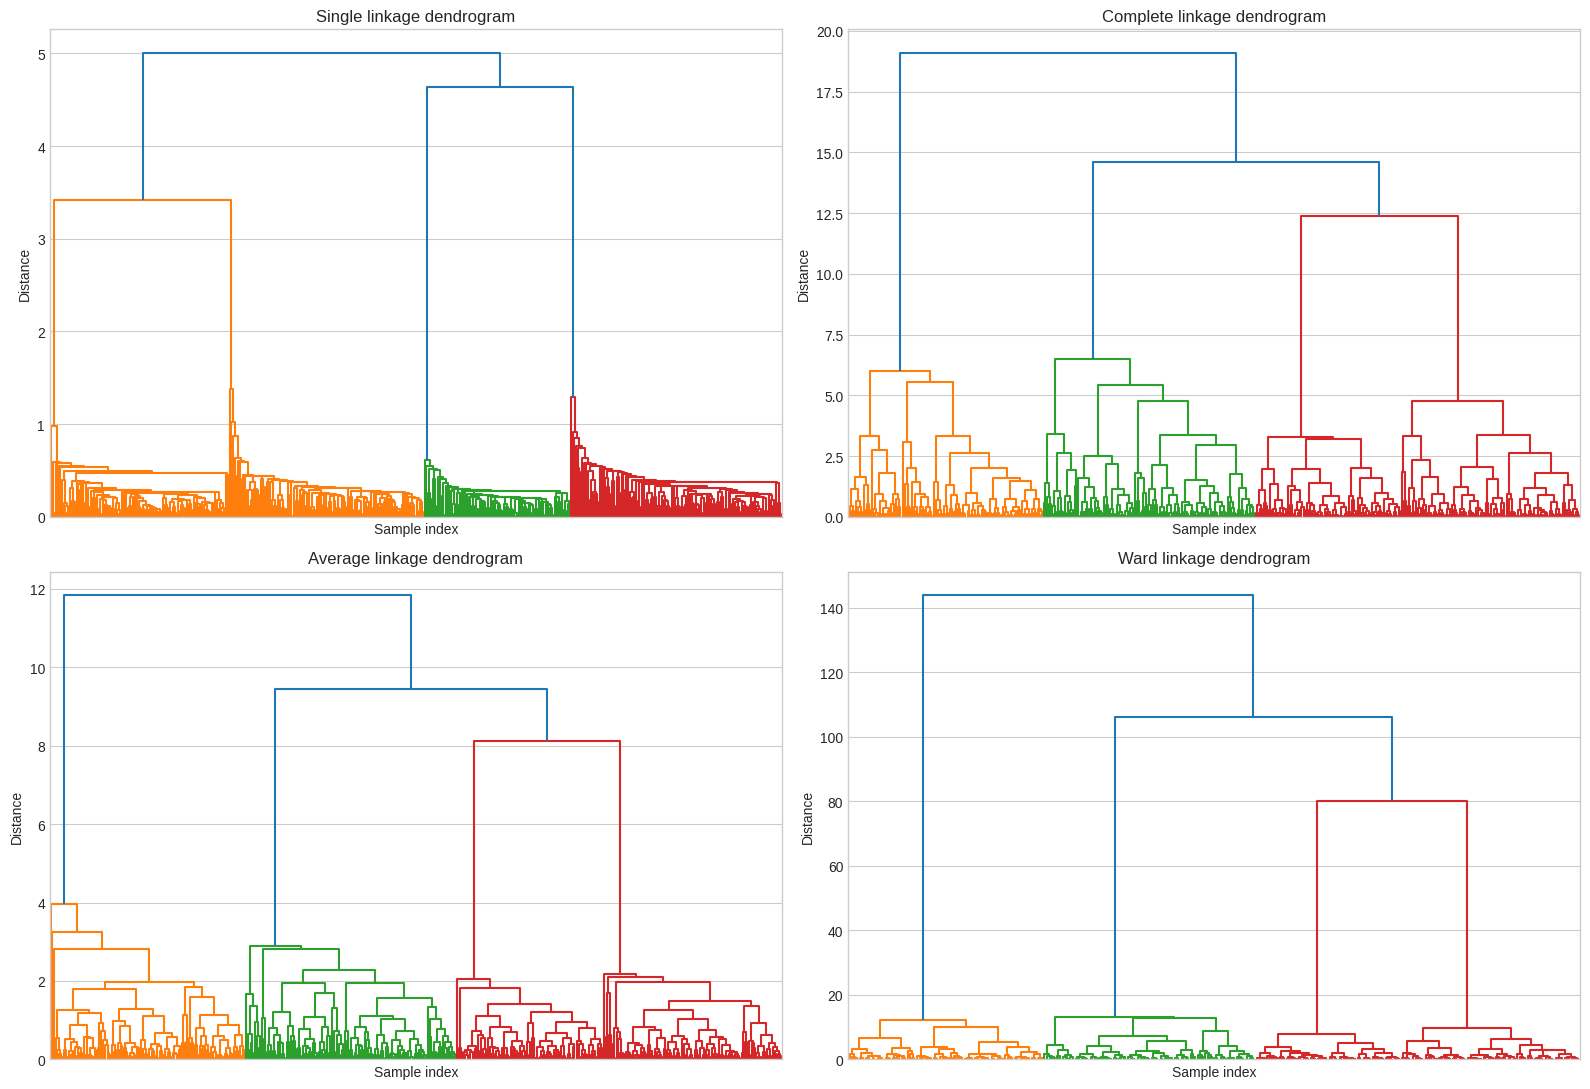

In [ ]:
```python\n# Let's visualize how the hierarchy looks for each method.\n# A dendrogram shows how points are merged into clusters based on distance.\nlinkage_methods = [\"single\", \"complete\", \"average\", \"ward\"]\n\nfig, axes = plt.subplots(2, 2, figsize=(16, 11))\n\nfor axis, method in zip(axes.ravel(), linkage_methods):\n    # Calculate the linkage matrix which encodes sample relationships\n    linkage_matrix = linkage(X_syn, method=method)\n    dendrogram(linkage_matrix, ax=axis, no_labels=True, color_threshold=None)\n    axis.set_title(f\"{method.title()} linkage dendrogram\")\n    axis.set_xlabel(\"Sample index\")\n    axis.set_ylabel(\"Distance\")\n\nplt.tight_layout()\nplt.show()\n```

NameError: name 'linkage_methods' is not defined

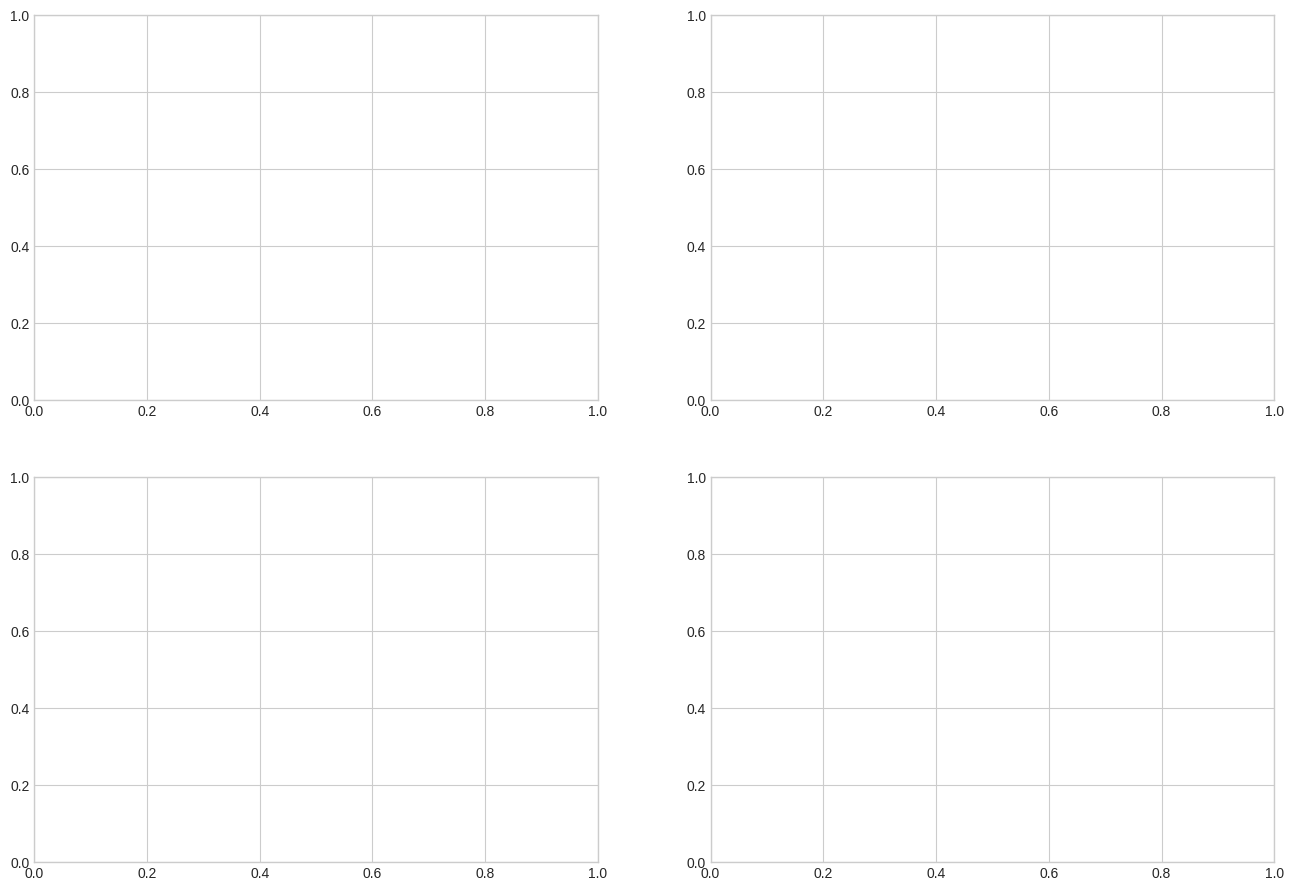

In [5]:
# Let's try Hierarchical clustering with different 'linkage' methods.
# Linkage determines how the distance between clusters is measured.
linkage_methods = ["single", "complete", "average", "ward"]

hierarchical_rows = []
hierarchical_sample_scores = {}
hierarchical_labels = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for axis, method in zip(axes.ravel(), linkage_methods):
    # We're telling it to find exactly 4 clusters
    model = AgglomerativeClustering(n_clusters=4, linkage=method)
    labels = model.fit_predict(X_syn)

    hierarchical_labels[method] = labels
    plot_cluster_map(
        X_syn,
        labels,
        title=f"{method.title()} linkage clusters",
        axis=axis,
        x_label="Feature 1",
        y_label="Feature 2",
    )

    # Recording how well it did for comparison later
    row, sample_scores = describe_clustering(
        X_syn,
        labels,
        model_name=f"Hierarchical - {method}",
    )
    hierarchical_rows.append(row)
    hierarchical_sample_scores[f"{method}_sample_silhouette"] = sample_scores

plt.tight_layout()
plt.show()

hierarchical_results = pd.DataFrame(hierarchical_rows).sort_values(
    by="silhouette_score",
    ascending=False,
)
display(hierarchical_results)

In [ ]:
hierarchical_silhouette_df = pd.DataFrame(hierarchical_sample_scores)
display(hierarchical_silhouette_df.head(10))
display(hierarchical_silhouette_df.describe().T[["mean", "min", "max"]])


,single_sample_silhouette,complete_sample_silhouette,average_sample_silhouette,ward_sample_silhouette
0,0.8697,0.8697,0.8697,0.8697
1,0.8281,0.8281,0.8281,0.8281
2,0.7870,0.7870,0.7870,0.7870
3,0.8651,0.8651,0.8651,0.8651
4,0.8772,0.8772,0.8772,0.8772
5,0.8750,0.8750,0.8750,0.8750
6,0.8497,0.8497,0.8497,0.8497
7,0.5098,0.5098,0.5098,0.5098
8,0.8696,0.8696,0.8696,0.8696
9,0.8265,0.8265,0.8265,0.8265


,mean,min,max
single_sample_silhouette,0.8057,0.3589,0.8936
complete_sample_silhouette,0.8057,0.3589,0.8936
average_sample_silhouette,0.8057,0.3589,0.8936
ward_sample_silhouette,0.8057,0.3589,0.8936


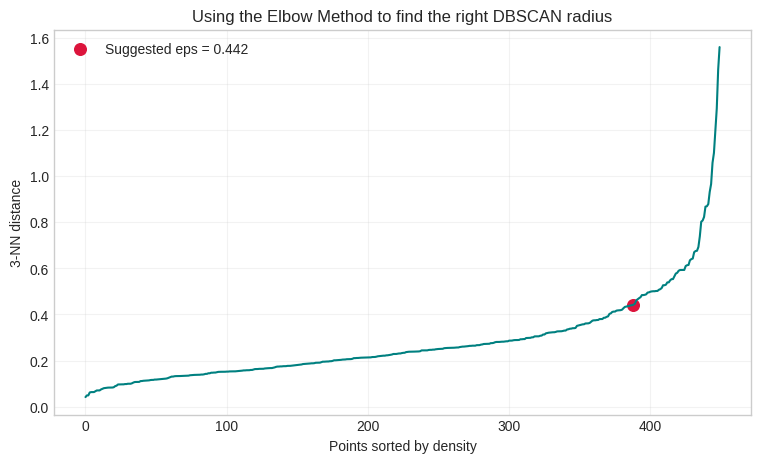

,model,cluster_count,noise_points,silhouette_score,eps
0,DBSCAN eps=0.243,33,169,-0.1590,0.243
1,DBSCAN eps=0.288,23,115,-0.0665,0.288
2,DBSCAN eps=0.332,19,84,0.0580,0.332
3,DBSCAN eps=0.376,15,68,0.0470,0.376
4,DBSCAN eps=0.42,12,47,0.1224,0.420
5,DBSCAN eps=0.464,11,37,0.3147,0.464
6,DBSCAN eps=0.509,6,31,0.5075,0.509
7,DBSCAN eps=0.553,4,24,0.7287,0.553
8,DBSCAN eps=0.597,4,16,0.7491,0.597
9,DBSCAN eps=0.641,4,10,0.7601,0.641


In [6]:
# DBSCAN is great but tricky to tune.
# We use the K-Nearest Neighbors distance to find a good 'eps' (radius).
min_samples_syn = X_syn.shape[1] + 1

nn_model_syn = NearestNeighbors(n_neighbors=min_samples_syn)
distances_syn, _ = nn_model_syn.fit(X_syn).kneighbors(X_syn)
# Looking at the distance to the k-th neighbor
k_distances_syn = np.sort(distances_syn[:, -1])

# The 'elbow' point is usually where the density drops and clusters end
suggested_eps_syn, elbow_index_syn = estimate_eps_from_k_distance(k_distances_syn)

plt.figure(figsize=(9, 5))
plt.plot(k_distances_syn, color="teal")
plt.scatter(
    elbow_index_syn,
    k_distances_syn[elbow_index_syn],
    color="crimson",
    s=70,
    label=f"Suggested eps = {suggested_eps_syn:.3f}",
)
plt.title("Using the Elbow Method to find the right DBSCAN radius")
plt.xlabel("Points sorted by density")
plt.ylabel(f"{min_samples_syn}-NN distance")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Even with the elbow, it's worth checking a few nearby values
eps_candidates_syn = np.unique(
    np.round(
        np.linspace(
            max(0.05, suggested_eps_syn * 0.55),
            suggested_eps_syn * 1.45,
            10,
        ),
        3,
    )
)

search_rows_syn = []
for eps in eps_candidates_syn:
    labels = DBSCAN(eps=float(eps), min_samples=min_samples_syn).fit_predict(X_syn)
    row, _ = describe_clustering(X_syn, labels, model_name=f"DBSCAN eps={eps}")
    row["eps"] = float(eps)
    search_rows_syn.append(row)

dbscan_search_syn = pd.DataFrame(search_rows_syn)
display(dbscan_search_syn.sort_values(by="eps"))

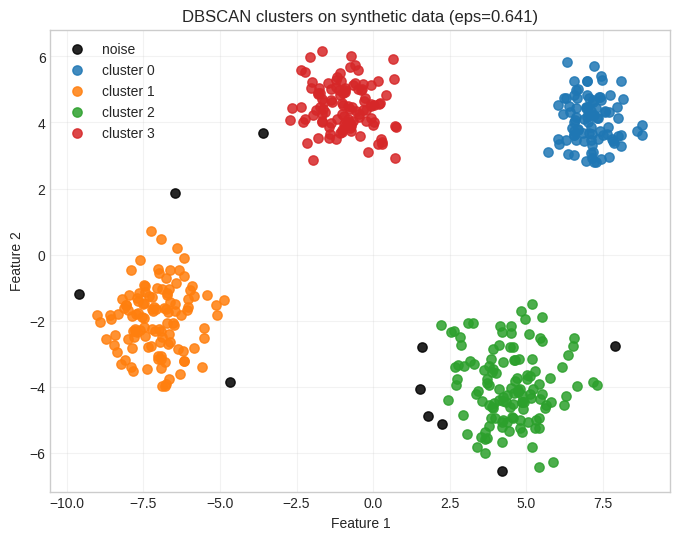

Chosen eps: 0.641
Total noise points found: 10


,model,cluster_count,noise_points,silhouette_score
0,"DBSCAN (eps=0.641, min_samples=3)",4,10,0.7601


,cluster_label,sample_silhouette
0,0,0.8693
1,1,0.8225
2,2,0.7628
3,0,0.8646
4,0,0.8765
5,0,0.8746
6,0,0.8488
7,2,0.5214
8,3,0.8715
9,0,0.8260


,sample_silhouette
count,450.0000
mean,0.7601
std,0.2160
min,-0.7395
25%,0.7483
50%,0.8038
75%,0.8494
max,0.8933


In [ ]:
valid_dbscan_syn = dbscan_search_syn.dropna(subset=["silhouette_score"]).copy()
valid_dbscan_syn = valid_dbscan_syn[valid_dbscan_syn["cluster_count"] >= 2].copy()

best_dbscan_syn = valid_dbscan_syn.sort_values(
    by=["silhouette_score", "noise_points"],
    ascending=[False, True],
).iloc[0]

best_eps_syn = float(best_dbscan_syn["eps"])
dbscan_syn = DBSCAN(eps=best_eps_syn, min_samples=min_samples_syn)
dbscan_syn_labels = dbscan_syn.fit_predict(X_syn)

dbscan_syn_row, dbscan_syn_sample_scores = describe_clustering(
    X_syn,
    dbscan_syn_labels,
    model_name=f"DBSCAN (eps={best_eps_syn:.3f}, min_samples={min_samples_syn})",
)

plt.figure(figsize=(8, 6))
plot_cluster_map(
    X_syn,
    dbscan_syn_labels,
    title=f"DBSCAN clusters on synthetic data (eps={best_eps_syn:.3f})",
    x_label="Feature 1",
    y_label="Feature 2",
)
plt.show()

print("Chosen eps:", round(best_eps_syn, 3))
print("Total noise points found:", dbscan_syn_row["noise_points"])

dbscan_syn_silhouette_df = pd.DataFrame(
    {
        "cluster_label": dbscan_syn_labels,
        "sample_silhouette": dbscan_syn_sample_scores,
    }
)

display(pd.DataFrame([dbscan_syn_row]))
display(dbscan_syn_silhouette_df.head(10))
display(dbscan_syn_silhouette_df["sample_silhouette"].describe())


In [ ]:
synthetic_comparison = pd.concat(
    [
        hierarchical_results,
        pd.DataFrame([dbscan_syn_row]),
    ],
    ignore_index=True,
).sort_values(by="silhouette_score", ascending=False)

display(synthetic_comparison)


,model,cluster_count,noise_points,silhouette_score
0,Hierarchical - single,4,0,0.8057
1,Hierarchical - complete,4,0,0.8057
2,Hierarchical - average,4,0,0.8057
3,Hierarchical - ward,4,0,0.8057
4,"DBSCAN (eps=0.641, min_samples=3)",4,10,0.7601


In [ ]:
```python\nfrom sklearn.datasets import load_iris\n\n# Now let's try a real-world classic: The Iris Dataset.\niris_bundle = load_iris(as_frame=True)\niris_features = iris_bundle.data.copy()\niris_target = iris_bundle.target.copy()\niris_names = iris_bundle.target_names\n\n# Pro tip: Always scale your data before clustering. \n# Distance metrics like Euclidean distance are sensitive to the magnitude of numbers.\nscaler = StandardScaler()\nX_iris_scaled = scaler.fit_transform(iris_features)\n\n# Iris has 4 features, but we only have 2D eyes. \n# PCA lets us squeeze those 4 dimensions into 2 while keeping as much info as possible.\npca = PCA(n_components=2)\nX_iris_pca = pca.fit_transform(X_iris_scaled)\n\nprint(\"Original Iris feature shape:\", iris_features.shape)\nprint(\"Scaled feature shape:\", X_iris_scaled.shape)\ndisplay(iris_features.head())\n```

Original Iris feature shape: (150, 4)
Scaled feature shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


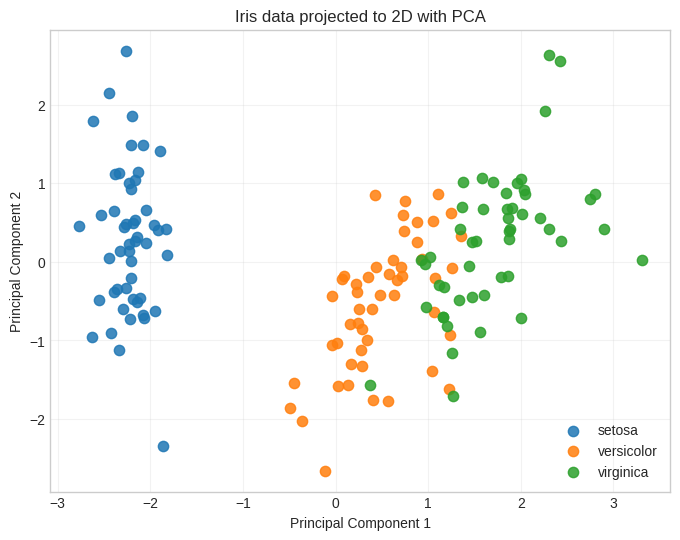

In [ ]:
```python\n# Let's see what the 'Ground Truth' looks like after PCA reduction.\nplt.figure(figsize=(8, 6))\n\nfor class_id, class_name in enumerate(iris_names):\n    mask = iris_target.to_numpy() == class_id\n    plt.scatter(\n        X_iris_pca[mask, 0],\n        X_iris_pca[mask, 1],\n        s=55,\n        alpha=0.85,\n        label=class_name,\n    )\n\nplt.title(\"Iris data projected to 2D: Note how some species overlap\")\nplt.xlabel(\"Principal Component 1\")\nplt.ylabel(\"Principal Component 2\")\nplt.legend()\nplt.grid(alpha=0.25)\nplt.show()\n```

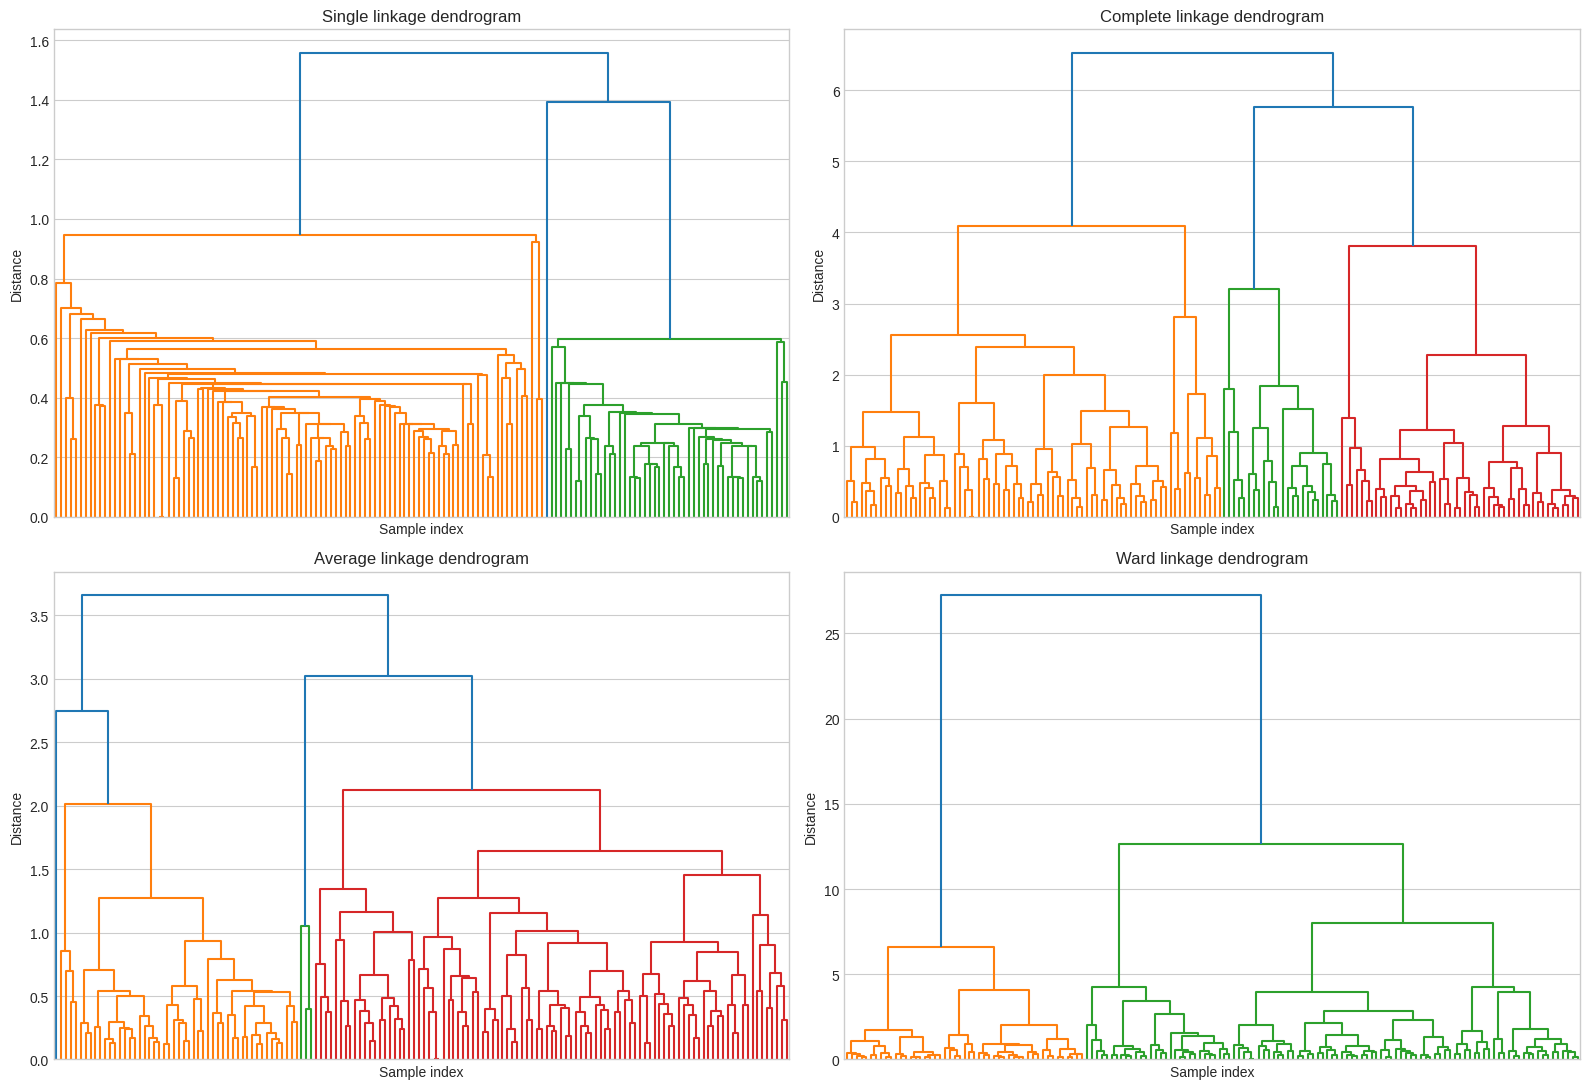

In [ ]:
linkage_methods = ["single", "complete", "average", "ward"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for axis, method in zip(axes.ravel(), linkage_methods):
    linkage_matrix = linkage(X_iris_scaled, method=method)
    dendrogram(linkage_matrix, ax=axis, no_labels=True, color_threshold=None)
    axis.set_title(f"{method.title()} linkage dendrogram")
    axis.set_xlabel("Sample index")
    axis.set_ylabel("Distance")

plt.tight_layout()
plt.show()


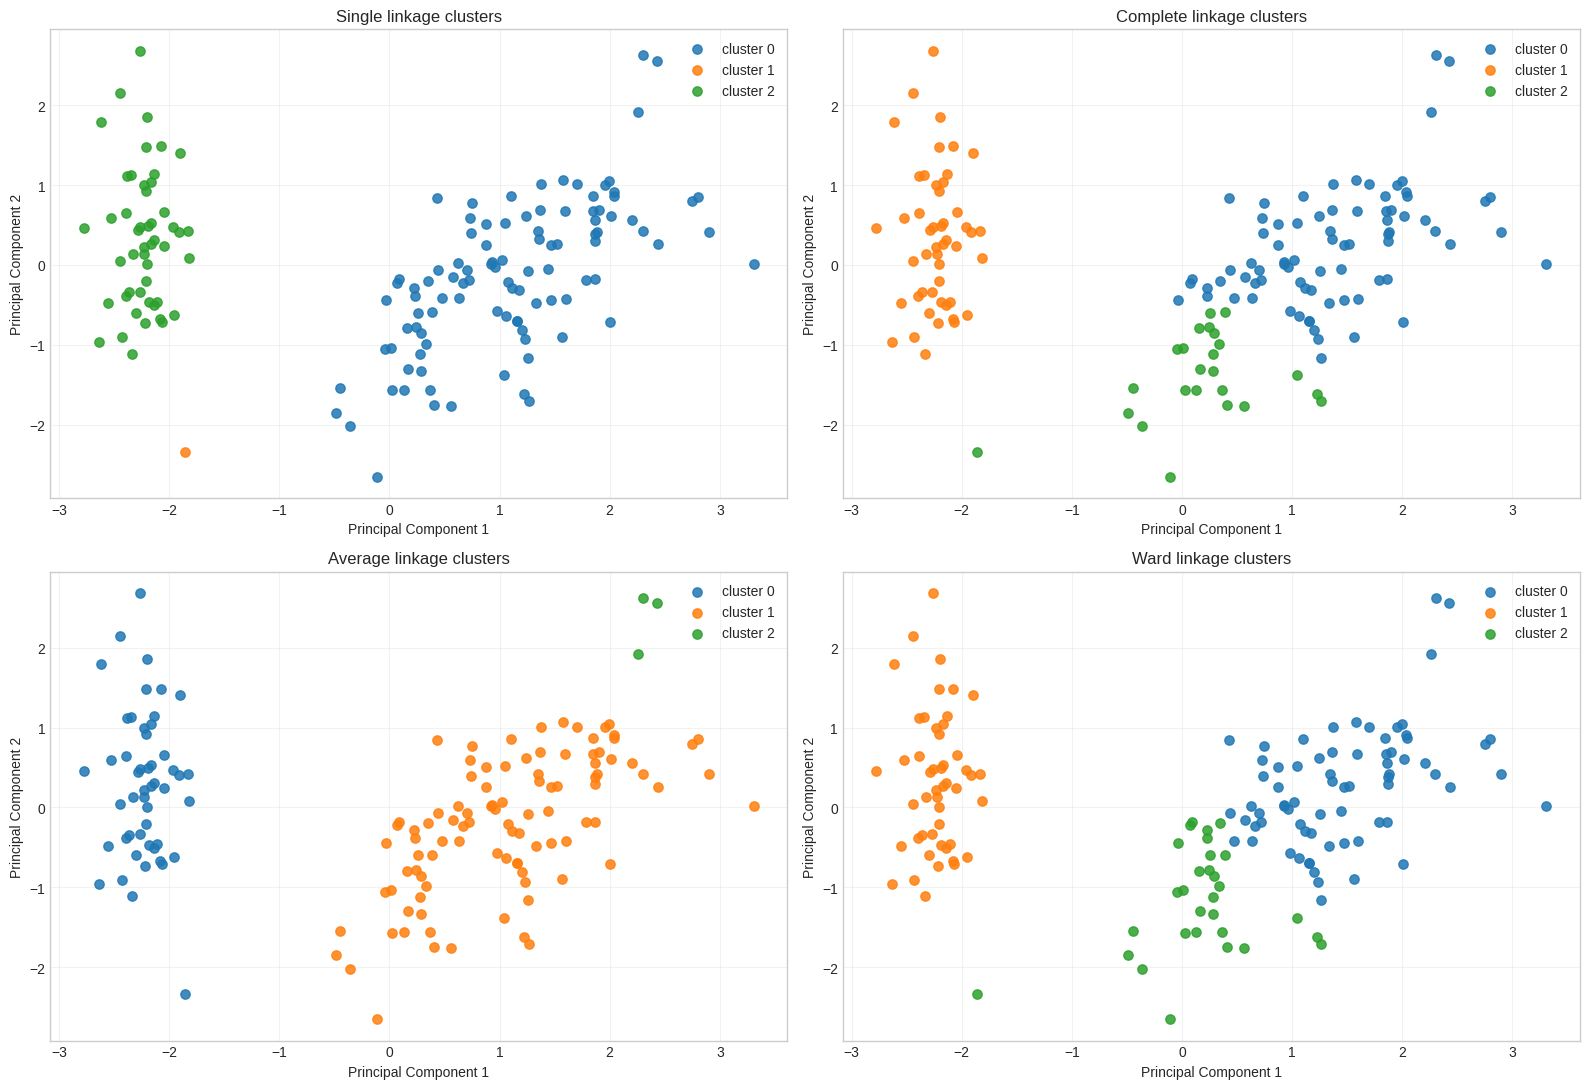

,model,cluster_count,noise_points,silhouette_score
0,Hierarchical - single,3,0,0.5046
2,Hierarchical - average,3,0,0.4803
1,Hierarchical - complete,3,0,0.4496
3,Hierarchical - ward,3,0,0.4467


In [ ]:
# Run Hierarchical clustering on the scaled Iris data and visualize the results
hierarchical_rows_iris = []
hierarchical_sample_scores_iris = {}
hierarchical_labels_iris = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for axis, method in zip(axes.ravel(), linkage_methods):
    # We fix n_clusters to 3 as we know there are 3 species of Iris
    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(X_iris_scaled)

    hierarchical_labels_iris[method] = labels
    plot_cluster_map(
        X_iris_pca,
        labels,
        title=f"{method.title()} linkage clusters",
        axis=axis,
        x_label="Principal Component 1",
        y_label="Principal Component 2",
    )

    # Calculate metrics for each linkage method
    row, sample_scores = describe_clustering(
        X_iris_scaled,
        labels,
        model_name=f"Hierarchical - {method}",
    )
    hierarchical_rows_iris.append(row)
    hierarchical_sample_scores_iris[f"{method}_sample_silhouette"] = sample_scores

plt.tight_layout()
plt.show()

# Sort results by silhouette score to find the most 'distinct' clustering
hierarchical_results_iris = pd.DataFrame(hierarchical_rows_iris).sort_values(
    by="silhouette_score",
    ascending=False,
)
display(hierarchical_results_iris)

In [ ]:
hierarchical_silhouette_df_iris = pd.DataFrame(hierarchical_sample_scores_iris)
display(hierarchical_silhouette_df_iris.head(10))
display(hierarchical_silhouette_df_iris.describe().T[["mean", "min", "max"]])


,single_sample_silhouette,complete_sample_silhouette,average_sample_silhouette,ward_sample_silhouette
0,0.7153,0.7438,0.7605,0.7340
1,0.2934,0.5225,0.6395,0.5171
2,0.5363,0.6607,0.7227,0.6533
3,0.3973,0.5882,0.6789,0.5815
4,0.7131,0.7400,0.7527,0.7299
5,0.6424,0.6396,0.6266,0.6222
6,0.6267,0.6960,0.7343,0.6863
7,0.6949,0.7352,0.7617,0.7258
8,-0.1006,0.4117,0.5747,0.4121
9,0.4539,0.6044,0.6874,0.5974


,mean,min,max
single_sample_silhouette,0.5046,-0.3825,0.7153
complete_sample_silhouette,0.4496,-0.2989,0.7438
average_sample_silhouette,0.4803,-0.2350,0.7945
ward_sample_silhouette,0.4467,-0.2304,0.7340


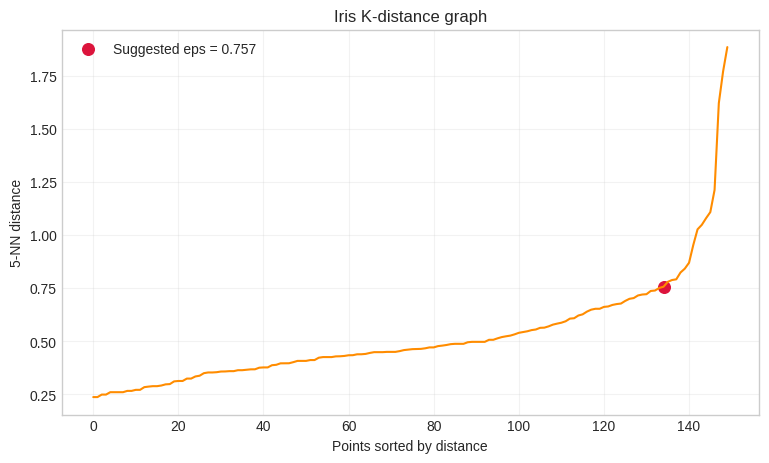

,model,cluster_count,noise_points,silhouette_score,eps
0,DBSCAN eps=0.416,5,63,0.0619,0.416
1,DBSCAN eps=0.492,2,36,0.3419,0.492
2,DBSCAN eps=0.568,2,29,0.3880,0.568
3,DBSCAN eps=0.643,2,15,0.4741,0.643
4,DBSCAN eps=0.719,2,6,0.5234,0.719
5,DBSCAN eps=0.795,2,4,0.5217,0.795
6,DBSCAN eps=0.87,2,4,0.5217,0.870
7,DBSCAN eps=0.946,2,4,0.5217,0.946
8,DBSCAN eps=1.022,2,3,0.5383,1.022
9,DBSCAN eps=1.097,2,2,0.5518,1.097


In [ ]:
# Now let's tune DBSCAN for the Iris data.
# We'll use the same 'elbow' trick on the scaled features.
min_samples_iris = X_iris_scaled.shape[1] + 1

nn_model_iris = NearestNeighbors(n_neighbors=min_samples_iris)
distances_iris, _ = nn_model_iris.fit(X_iris_scaled).kneighbors(X_iris_scaled)
k_distances_iris = np.sort(distances_iris[:, -1])

# Finding the point where the distance starts to spike
suggested_eps_iris, elbow_index_iris = estimate_eps_from_k_distance(k_distances_iris)

plt.figure(figsize=(9, 5))
plt.plot(k_distances_iris, color="darkorange")
plt.scatter(
    elbow_index_iris,
    k_distances_iris[elbow_index_iris],
    color="crimson",
    s=70,
    label=f"Suggested eps = {suggested_eps_iris:.3f}",
)
plt.title("Finding the right density threshold (eps) for Iris")
plt.xlabel("Points sorted by density")
plt.ylabel(f"{min_samples_iris}-NN distance")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Let's search around that suggested value to find the best fit
eps_candidates_iris = np.unique(
    np.round(
        np.linspace(
            max(0.10, suggested_eps_iris * 0.55),
            suggested_eps_iris * 1.45,
            10,
        ),
        3,
    )
)

search_rows_iris = []
for eps in eps_candidates_iris:
    labels = DBSCAN(eps=float(eps), min_samples=min_samples_iris).fit_predict(X_iris_scaled)
    row, _ = describe_clustering(X_iris_scaled, labels, model_name=f"DBSCAN eps={eps}")
    row["eps"] = float(eps)
    search_rows_iris.append(row)

dbscan_search_iris = pd.DataFrame(search_rows_iris)
display(dbscan_search_iris.sort_values(by="eps"))

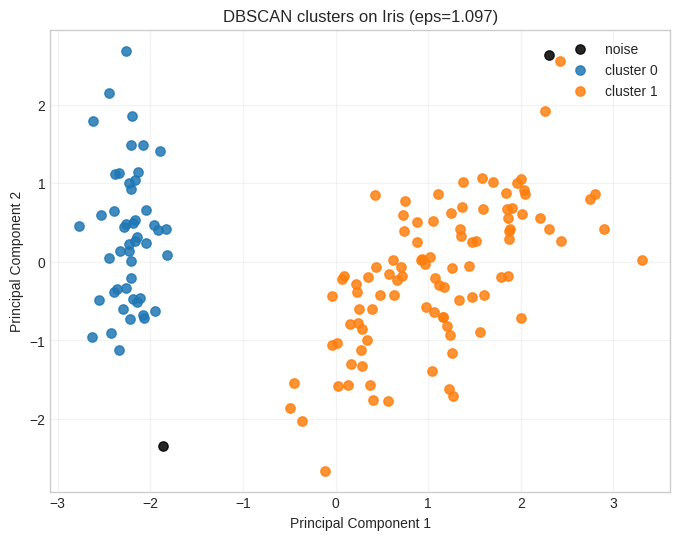

Chosen eps: 1.097
Total noise points found: 2


,model,cluster_count,noise_points,silhouette_score
0,"DBSCAN (eps=1.097, min_samples=5)",2,2,0.5518


,cluster_label,sample_silhouette
0,0,0.7740
1,0,0.6467
2,0,0.7319
3,0,0.6866
4,0,0.7663
5,0,0.6416
6,0,0.7453
7,0,0.7742
8,0,0.5788
9,0,0.6960


,sample_silhouette
count,150.0000
mean,0.5518
std,0.1868
min,-0.5773
25%,0.4845
50%,0.5786
75%,0.6497
max,0.7742


In [ ]:
valid_dbscan_iris = dbscan_search_iris.dropna(subset=["silhouette_score"]).copy()
valid_dbscan_iris = valid_dbscan_iris[valid_dbscan_iris["cluster_count"] >= 2].copy()

best_dbscan_iris = valid_dbscan_iris.sort_values(
    by=["silhouette_score", "noise_points"],
    ascending=[False, True],
).iloc[0]

best_eps_iris = float(best_dbscan_iris["eps"])
dbscan_iris = DBSCAN(eps=best_eps_iris, min_samples=min_samples_iris)
dbscan_iris_labels = dbscan_iris.fit_predict(X_iris_scaled)

dbscan_iris_row, dbscan_iris_sample_scores = describe_clustering(
    X_iris_scaled,
    dbscan_iris_labels,
    model_name=f"DBSCAN (eps={best_eps_iris:.3f}, min_samples={min_samples_iris})",
)

plt.figure(figsize=(8, 6))
plot_cluster_map(
    X_iris_pca,
    dbscan_iris_labels,
    title=f"DBSCAN clusters on Iris (eps={best_eps_iris:.3f})",
    x_label="Principal Component 1",
    y_label="Principal Component 2",
)
plt.show()

print("Chosen eps:", round(best_eps_iris, 3))
print("Total noise points found:", dbscan_iris_row["noise_points"])

dbscan_iris_silhouette_df = pd.DataFrame(
    {
        "cluster_label": dbscan_iris_labels,
        "sample_silhouette": dbscan_iris_sample_scores,
    }
)

display(pd.DataFrame([dbscan_iris_row]))
display(dbscan_iris_silhouette_df.head(10))
display(dbscan_iris_silhouette_df["sample_silhouette"].describe())


In [ ]:
# Time for the final showdown!
# Let's see how our Hierarchical models compare against the tuned DBSCAN.
iris_comparison = pd.concat(
    [
        hierarchical_results_iris,
        pd.DataFrame([dbscan_iris_row]),
    ],
    ignore_index=True,
).sort_values(by="silhouette_score", ascending=False)

print("Final Model Performance Comparison (Iris Dataset):")
display(iris_comparison)

,model,cluster_count,noise_points,silhouette_score
4,"DBSCAN (eps=1.097, min_samples=5)",2,2,0.5518
0,Hierarchical - single,3,0,0.5046
1,Hierarchical - average,3,0,0.4803
2,Hierarchical - complete,3,0,0.4496
3,Hierarchical - ward,3,0,0.4467
